# Phase 8-2: 추론 서버와 최적화
> "추론 최적화의 본질은 '모델을 빠르게 하는 것'이 아니라 'GPU의 빈 시간을 없애는 것'이다."

## 학습 목표
1. model.generate()의 한계를 이해한다
2. KV-Cache의 원리와 효과를 이해한다
3. PagedAttention과 Continuous Batching을 이해한다
4. vLLM 서버를 실행하고 API로 호출한다
5. FastAPI + vLLM 커스텀 서버를 구축한다
6. Flash Attention, Speculative Decoding 개념을 이해한다

In [ ]:
# 추론 최적화 라이브러리 설치
# vLLM: Linux/WSL2에서만 설치 가능 (Windows native 미지원)
# !pip install vllm  # Linux/WSL2
# !pip install transformers torch accelerate fastapi uvicorn requests -q

In [3]:
import torch
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name} ({gpu.total_memory // 1024**3}GB)")
else:
    print("CPU 모드")

import platform
print(f"OS: {platform.system()} {platform.release()}")
if platform.system() == "Windows":
    print("vLLM은 Linux/WSL2에서만 실행됩니다.")
    print("   Windows에서는 코드 학습 + HF pipeline fallback을 사용합니다.")

print(f"실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

GPU: NVIDIA GeForce RTX 4070 Ti (11GB)
OS: Windows 10
vLLM은 Linux/WSL2에서만 실행됩니다.
   Windows에서는 코드 학습 + HF pipeline fallback을 사용합니다.
실행 시각: 2026-03-19 14:09


---
## 1. model.generate()의 한계

### HuggingFace의 기본 추론
```python
output = model.generate(input_ids, max_new_tokens=256)
```

### 문제점
| 한계 | 설명 | 영향 |
|------|------|------|
| **동기 처리** | 한 번에 하나의 요청만 처리 | 대기 시간 ↑↑ |
| **Static Batching** | 모든 시퀀스가 같은 길이로 패딩 | VRAM 낭비 |
| **KV-Cache 미관리** | 메모리를 연속으로 할당 → 단편화 | OOM 위험 |
| **최적화 없음** | 순수 PyTorch 연산 | 속도 ↓ |

### 성능 비교 (Qwen 1.5B, 256 tokens)
| 방식 | Tokens/sec | 동시 요청 |
|------|:---------:|:--------:|
| model.generate() | ~40 | 1 |
| vLLM | ~150+ | 수십~수백 |

→ **프로덕션에서 model.generate()를 직접 쓰면 안 된다!**

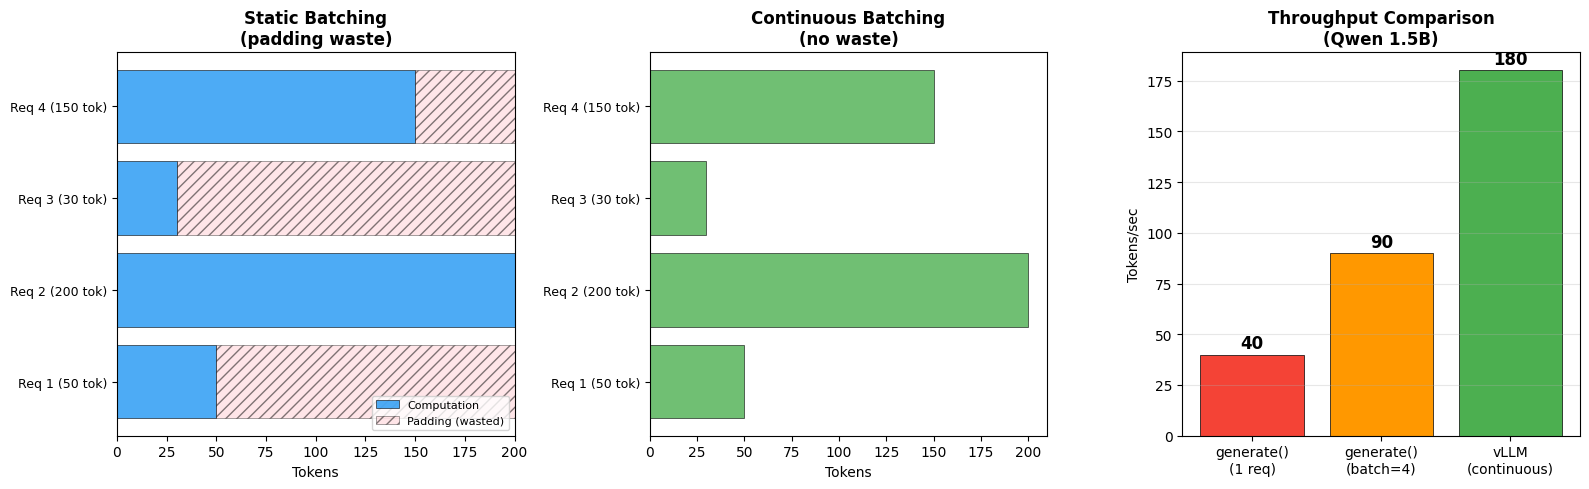

Static Batching은 가장 긴 시퀀스에 맞춰 패딩 -> GPU 자원 낭비
Continuous Batching은 완료된 요청을 즉시 교체 -> GPU 활용률 극대화


In [4]:
# model.generate()의 한계 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Static vs Continuous Batching
ax = axes[0]
# Static batching: all padded to max length
requests = ['Req 1 (50 tok)', 'Req 2 (200 tok)', 'Req 3 (30 tok)', 'Req 4 (150 tok)']
actual_lengths = [50, 200, 30, 150]
max_len = 200

for i, (req, length) in enumerate(zip(requests, actual_lengths)):
    # Actual computation
    ax.barh(i, length, color='#2196F3', alpha=0.8, edgecolor='black', linewidth=0.5)
    # Padding (wasted)
    ax.barh(i, max_len - length, left=length, color='#FFCDD2', alpha=0.5, 
            edgecolor='black', linewidth=0.5, hatch='///')
    
ax.set_yticks(range(len(requests)))
ax.set_yticklabels(requests, fontsize=9)
ax.set_xlabel('Tokens')
ax.set_title('Static Batching\n(padding waste)', fontsize=12, fontweight='bold')
ax.legend(['Computation', 'Padding (wasted)'], loc='lower right', fontsize=8)

# Panel 2: Continuous Batching
ax = axes[1]
# No padding, requests processed as they complete
times = [0, 0, 0, 0]
for i, (req, length) in enumerate(zip(requests, actual_lengths)):
    ax.barh(i, length, color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(requests)))
ax.set_yticklabels(requests, fontsize=9)
ax.set_xlabel('Tokens')
ax.set_title('Continuous Batching\n(no waste)', fontsize=12, fontweight='bold')

# Panel 3: Throughput comparison
methods = ['generate()\n(1 req)', 'generate()\n(batch=4)', 'vLLM\n(continuous)']
throughput = [40, 90, 180]
colors_tp = ['#F44336', '#FF9800', '#4CAF50']

bars = ax2 = axes[2]
bars = axes[2].bar(methods, throughput, color=colors_tp, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Tokens/sec')
axes[2].set_title('Throughput Comparison\n(Qwen 1.5B)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

for bar, tp in zip(bars, throughput):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{tp}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print("Static Batching은 가장 긴 시퀀스에 맞춰 패딩 -> GPU 자원 낭비")
print("Continuous Batching은 완료된 요청을 즉시 교체 -> GPU 활용률 극대화")

---
## 2. KV-Cache: 반복 계산 제거

### 문제: Autoregressive 생성의 비효율
- 토큰 1개 생성할 때마다 **모든 이전 토큰**을 다시 처리
- 100번째 토큰 생성 시: 이전 99개 토큰의 Attention을 다시 계산
- 계산량: O(n^2) → n이 길어질수록 급격히 느려짐

### 해결: KV-Cache
- 이전 토큰의 Key, Value를 **캐시에 저장**
- 새 토큰은 자신의 Query만 계산하면 됨
- 계산량: O(n^2) → O(n) (이미 계산된 KV를 재사용)

### 메모리 비용
```
KV-Cache 크기 = 2 x num_layers x hidden_size x seq_length x batch_size x dtype_size
Qwen 1.5B:     2 x 28 x 1536 x 2048 x 1 x 2 bytes = 340 MB (한 요청)
```

- 동시 요청이 많아지면 KV-Cache가 VRAM의 주요 소비자가 됨
- → PagedAttention이 이 문제를 해결

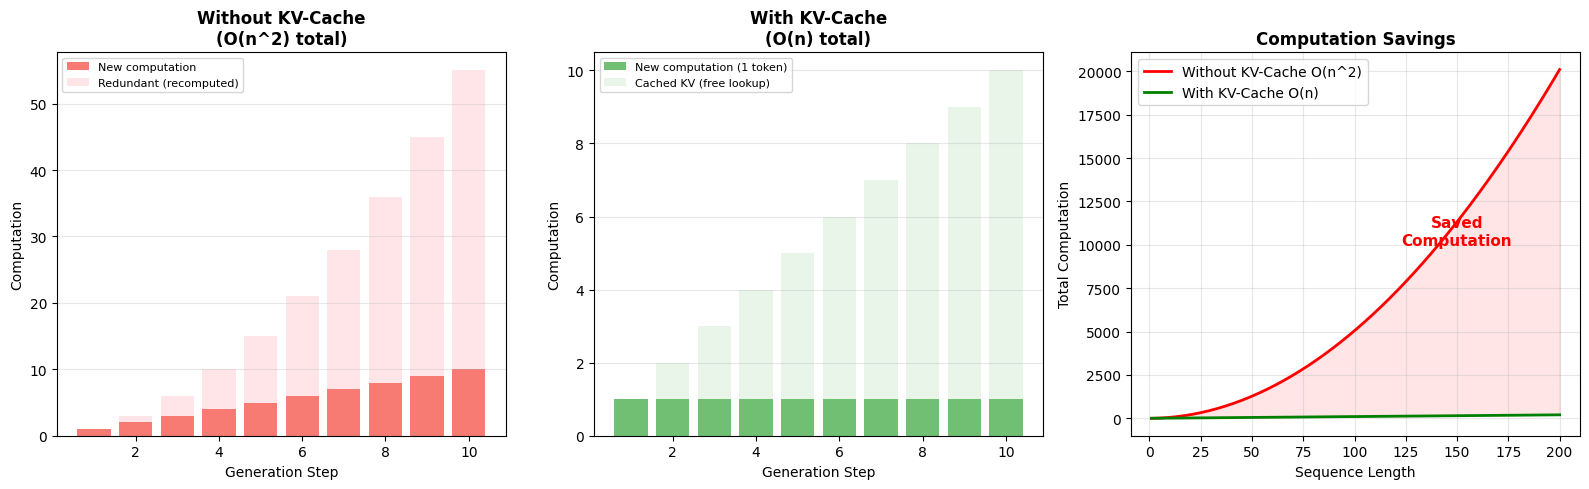

KV-Cache는 '메모리를 써서 계산을 줄이는' 전형적인 space-time tradeoff
길이 200 토큰에서 약 100배의 중복 계산을 제거


In [5]:
# KV-Cache 원리 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Without KV-Cache (O(n^2))
ax = axes[0]
seq_lengths = np.arange(1, 11)
# Without cache: each step processes all previous tokens
computations_no_cache = np.cumsum(seq_lengths)

ax.bar(seq_lengths, seq_lengths, color='#F44336', alpha=0.7, label='New computation')
ax.bar(seq_lengths, computations_no_cache - seq_lengths, bottom=seq_lengths, 
       color='#FFCDD2', alpha=0.5, label='Redundant (recomputed)')
ax.set_xlabel('Generation Step')
ax.set_ylabel('Computation')
ax.set_title('Without KV-Cache\n(O(n^2) total)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: With KV-Cache (O(n))
ax = axes[1]
ax.bar(seq_lengths, np.ones_like(seq_lengths), color='#4CAF50', alpha=0.8, label='New computation (1 token)')
ax.bar(seq_lengths, seq_lengths - 1, bottom=np.ones_like(seq_lengths),
       color='#C8E6C9', alpha=0.4, label='Cached KV (free lookup)')
ax.set_xlabel('Generation Step')
ax.set_ylabel('Computation')
ax.set_title('With KV-Cache\n(O(n) total)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Total computation comparison
ax = axes[2]
n = np.arange(1, 201)
no_cache_total = n * (n + 1) / 2  # O(n^2)
with_cache_total = n  # O(n)

ax.plot(n, no_cache_total, 'r-', linewidth=2, label='Without KV-Cache O(n^2)')
ax.plot(n, with_cache_total, 'g-', linewidth=2, label='With KV-Cache O(n)')
ax.fill_between(n, with_cache_total, no_cache_total, alpha=0.1, color='red')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Total Computation')
ax.set_title('Computation Savings', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(150, 10000, 'Saved\nComputation', fontsize=11, color='red', 
        ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("KV-Cache는 '메모리를 써서 계산을 줄이는' 전형적인 space-time tradeoff")
print("길이 200 토큰에서 약 100배의 중복 계산을 제거")

---
## 3. PagedAttention과 Continuous Batching (vLLM 핵심)

### PagedAttention
- OS의 **가상 메모리 페이징**을 KV-Cache에 적용
- KV-Cache를 고정 크기 **페이지(블록)**로 분할
- 연속 메모리가 필요 없음 → 단편화 해결 → 메모리 활용률 ↑↑

### Continuous Batching
- 기존: 배치의 모든 요청이 끝날 때까지 대기 (Static Batching)
- vLLM: 한 요청이 끝나면 즉시 새 요청을 슬롯에 삽입
- 결과: GPU가 쉬는 시간이 거의 없음

### 함께 사용할 때의 시너지
| 최적화 | 단독 효과 | 결합 효과 |
|--------|---------|--------|
| KV-Cache | 토큰당 계산 O(n)→O(1) | — |
| PagedAttention | 메모리 활용률 +30-50% | — |
| Continuous Batching | 처리량 +2-3x | — |
| **KV + Paged + Continuous** | — | **처리량 +5-10x** |

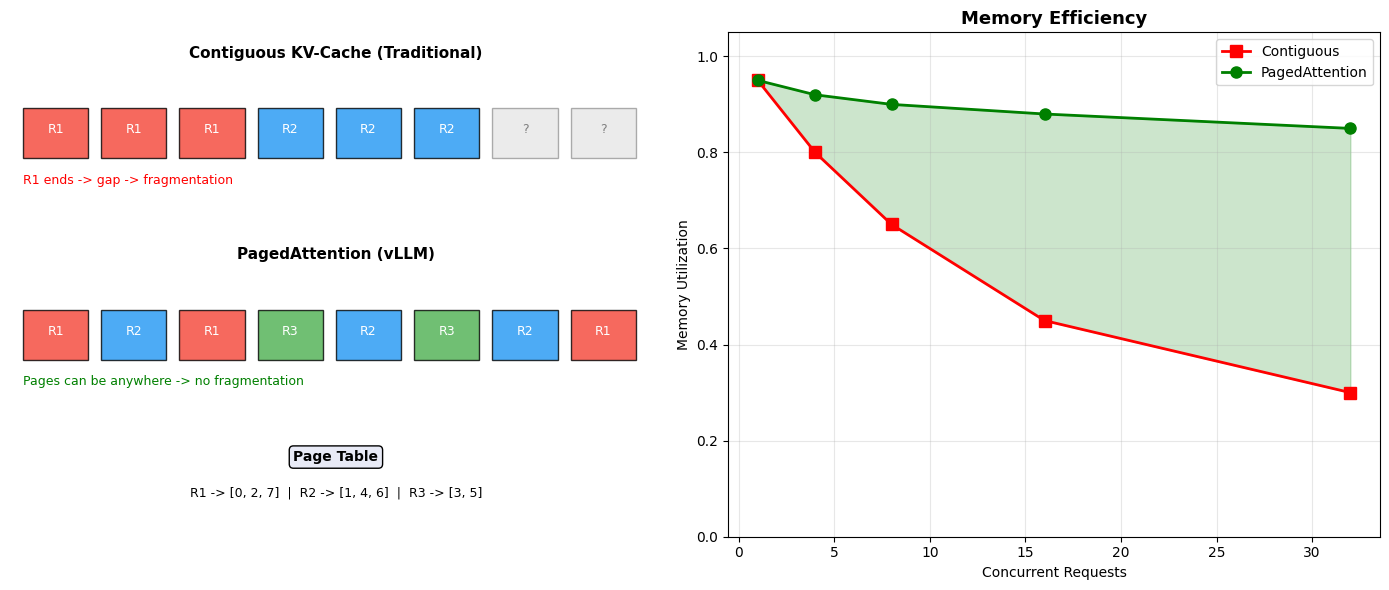

PagedAttention = OS의 가상 메모리를 KV-Cache에 적용
동시 요청이 많을수록 효과가 커진다


In [6]:
# PagedAttention 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Contiguous vs Paged memory
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Contiguous memory (top)
ax.text(5, 9.5, 'Contiguous KV-Cache (Traditional)', ha='center', fontsize=11, fontweight='bold')
# Memory blocks
for i in range(8):
    color = '#F44336' if i < 3 else ('#2196F3' if i < 6 else '#BDBDBD')
    alpha = 0.8 if i < 6 else 0.3
    ax.add_patch(plt.Rectangle((i * 1.2 + 0.2, 7.5), 1.0, 1.0, 
                                facecolor=color, alpha=alpha, edgecolor='black'))
    if i < 3:
        ax.text(i * 1.2 + 0.7, 8.0, f'R1', ha='center', fontsize=9, color='white')
    elif i < 6:
        ax.text(i * 1.2 + 0.7, 8.0, f'R2', ha='center', fontsize=9, color='white')
    else:
        ax.text(i * 1.2 + 0.7, 8.0, '?', ha='center', fontsize=9, color='gray')

ax.text(0.2, 7.0, 'R1 ends -> gap -> fragmentation', fontsize=9, color='red')

# Paged memory (bottom)
ax.text(5, 5.5, 'PagedAttention (vLLM)', ha='center', fontsize=11, fontweight='bold')
page_colors = ['#F44336', '#2196F3', '#F44336', '#4CAF50', '#2196F3', '#4CAF50', '#2196F3', '#F44336']
page_labels = ['R1', 'R2', 'R1', 'R3', 'R2', 'R3', 'R2', 'R1']
for i in range(8):
    ax.add_patch(plt.Rectangle((i * 1.2 + 0.2, 3.5), 1.0, 1.0, 
                                facecolor=page_colors[i], alpha=0.8, edgecolor='black'))
    ax.text(i * 1.2 + 0.7, 4.0, page_labels[i], ha='center', fontsize=9, color='white')

ax.text(0.2, 3.0, 'Pages can be anywhere -> no fragmentation', fontsize=9, color='green')

# Page table
ax.text(5, 1.5, 'Page Table', ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E8EAF6'))
ax.text(5, 0.8, 'R1 -> [0, 2, 7]  |  R2 -> [1, 4, 6]  |  R3 -> [3, 5]', 
        ha='center', fontsize=9)

# Panel 2: Memory efficiency comparison
ax = axes[1]
batch_sizes = [1, 4, 8, 16, 32]
contiguous_util = [0.95, 0.80, 0.65, 0.45, 0.30]  # decreases with fragmentation
paged_util = [0.95, 0.92, 0.90, 0.88, 0.85]  # stays high

ax.plot(batch_sizes, contiguous_util, 'r-s', linewidth=2, markersize=8, label='Contiguous')
ax.plot(batch_sizes, paged_util, 'g-o', linewidth=2, markersize=8, label='PagedAttention')
ax.fill_between(batch_sizes, contiguous_util, paged_util, alpha=0.2, color='green')
ax.set_xlabel('Concurrent Requests')
ax.set_ylabel('Memory Utilization')
ax.set_title('Memory Efficiency', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()
print("PagedAttention = OS의 가상 메모리를 KV-Cache에 적용")
print("동시 요청이 많을수록 효과가 커진다")

---
## 4. vLLM 실전

### 플랫폼 요구사항
- **Linux**: 직접 설치 가능
- **Windows**: WSL2 필요 (네이티브 미지원)
- **macOS**: Apple Silicon 지원 (실험적)

### vLLM 서버 실행
```bash
# 설치 (Linux/WSL2)
pip install vllm

# 서버 실행 (OpenAI-compatible API)
python -m vllm.entrypoints.openai.api_server \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --dtype float16 \
    --max-model-len 2048 \
    --port 8000

# 양자화 모델 사용
python -m vllm.entrypoints.openai.api_server \
    --model ./qwen-1.5b-awq-4bit \
    --quantization awq \
    --dtype float16 \
    --port 8000
```

In [7]:
# ============================================================
# vLLM 서버 실행 + OpenAI-compatible API 호출
# ============================================================

# === 1. vLLM 서버 시작 명령어 ===
print("=" * 60)
print("vLLM 서버 실행 (터미널에서)")
print("=" * 60)

vllm_cmd = """
# 기본 실행
python -m vllm.entrypoints.openai.api_server \\
    --model Qwen/Qwen2.5-1.5B-Instruct \\
    --dtype float16 \\
    --max-model-len 2048 \\
    --gpu-memory-utilization 0.85 \\
    --port 8000

# AWQ 양자화 모델
python -m vllm.entrypoints.openai.api_server \\
    --model ./qwen-1.5b-awq-4bit \\
    --quantization awq \\
    --dtype float16 \\
    --max-model-len 2048 \\
    --port 8000
"""
print(vllm_cmd)

# === 2. API 호출 코드 ===
print("=" * 60)
print("OpenAI-compatible API 호출")
print("=" * 60)

api_code = '''
import requests

# vLLM은 OpenAI API와 동일한 형식을 지원
response = requests.post(
    "http://localhost:8000/v1/chat/completions",
    json={
        "model": "Qwen/Qwen2.5-1.5B-Instruct",
        "messages": [
            {"role": "system", "content": "You are a SQL expert."},
            {"role": "user", "content": "employees 테이블에서 급여 상위 5명을 조회해줘"}
        ],
        "max_tokens": 256,
        "temperature": 0.1,
    }
)

result = response.json()
print(result["choices"][0]["message"]["content"])

# Streaming 지원
response = requests.post(
    "http://localhost:8000/v1/chat/completions",
    json={
        "model": "Qwen/Qwen2.5-1.5B-Instruct",
        "messages": [{"role": "user", "content": "Hello"}],
        "stream": True,
    },
    stream=True,
)
for chunk in response.iter_lines():
    if chunk:
        print(chunk.decode())
'''
print(api_code)

# === 3. Python 클라이언트 (openai 패키지 사용) ===
print("\n" + "=" * 60)
print("OpenAI Python 패키지로 호출")
print("=" * 60)

openai_code = '''
from openai import OpenAI

# vLLM 서버를 OpenAI 클라이언트로 호출
client = OpenAI(
    base_url="http://localhost:8000/v1",
    api_key="not-needed",  # vLLM은 API key 불필요
)

response = client.chat.completions.create(
    model="Qwen/Qwen2.5-1.5B-Instruct",
    messages=[
        {"role": "system", "content": "You are a SQL expert."},
        {"role": "user", "content": "부서별 평균 급여를 조회하는 SQL을 작성해줘"}
    ],
    max_tokens=256,
    temperature=0.1,
)
print(response.choices[0].message.content)
'''
print(openai_code)
print("\nvLLM -> OpenAI API 호환 -> 기존 코드 수정 없이 교체 가능!")

vLLM 서버 실행 (터미널에서)

# 기본 실행
python -m vllm.entrypoints.openai.api_server \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --dtype float16 \
    --max-model-len 2048 \
    --gpu-memory-utilization 0.85 \
    --port 8000

# AWQ 양자화 모델
python -m vllm.entrypoints.openai.api_server \
    --model ./qwen-1.5b-awq-4bit \
    --quantization awq \
    --dtype float16 \
    --max-model-len 2048 \
    --port 8000

OpenAI-compatible API 호출

import requests

# vLLM은 OpenAI API와 동일한 형식을 지원
response = requests.post(
    "http://localhost:8000/v1/chat/completions",
    json={
        "model": "Qwen/Qwen2.5-1.5B-Instruct",
        "messages": [
            {"role": "system", "content": "You are a SQL expert."},
            {"role": "user", "content": "employees 테이블에서 급여 상위 5명을 조회해줘"}
        ],
        "max_tokens": 256,
        "temperature": 0.1,
    }
)

result = response.json()
print(result["choices"][0]["message"]["content"])

# Streaming 지원
response = requests.post(
    "http://localhost:8000/v1/cha

---
## 5. FastAPI + vLLM 커스텀 서버

vLLM의 기본 API 서버로 충분하지 않을 때, FastAPI로 커스텀 서버를 구축한다.

### 커스텀 서버가 필요한 경우
- 인증/권한 관리
- 요청/응답 전처리/후처리
- 로깅, 모니터링
- 여러 모델 서빙
- 비즈니스 로직 추가

In [8]:
# ============================================================
# FastAPI + vLLM 커스텀 서버 코드
# ============================================================

server_code = '''
# === server.py ===
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from vllm import LLM, SamplingParams
import time

app = FastAPI(title="SQL Generator API")

# 모델 로드 (서버 시작 시 1회)
llm = LLM(
    model="Qwen/Qwen2.5-1.5B-Instruct",
    dtype="float16",
    max_model_len=2048,
    gpu_memory_utilization=0.85,
)

class SQLRequest(BaseModel):
    question: str
    max_tokens: int = 256
    temperature: float = 0.1

class SQLResponse(BaseModel):
    sql: str
    latency_ms: float
    tokens_generated: int

SYSTEM_PROMPT = """You are a SQL expert. Given a natural language question, 
generate the corresponding SQL query. Only output the SQL query, nothing else."""

@app.post("/generate_sql", response_model=SQLResponse)
async def generate_sql(request: SQLRequest):
    start_time = time.time()
    
    # 프롬프트 구성
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": request.question}
    ]
    
    # 토크나이저의 chat template 적용
    tokenizer = llm.get_tokenizer()
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    # 생성
    sampling_params = SamplingParams(
        max_tokens=request.max_tokens,
        temperature=request.temperature,
        top_p=0.9,
    )
    
    outputs = llm.generate([prompt], sampling_params)
    generated_text = outputs[0].outputs[0].text.strip()
    
    latency = (time.time() - start_time) * 1000
    
    return SQLResponse(
        sql=generated_text,
        latency_ms=round(latency, 1),
        tokens_generated=len(outputs[0].outputs[0].token_ids),
    )

@app.get("/health")
async def health():
    return {"status": "healthy", "model": "Qwen/Qwen2.5-1.5B-Instruct"}

# 실행: uvicorn server:app --host 0.0.0.0 --port 8000
'''

print("=" * 60)
print("FastAPI + vLLM 커스텀 서버")
print("=" * 60)
print(server_code)

# Windows fallback
print("\n" + "=" * 60)
print("Windows Fallback: HuggingFace Pipeline 서버")
print("=" * 60)

fallback_code = '''
# === server_hf.py (Windows compatible) ===
from fastapi import FastAPI
from pydantic import BaseModel
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch, time

app = FastAPI(title="SQL Generator API (HF Fallback)")

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
)
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

class SQLRequest(BaseModel):
    question: str
    max_tokens: int = 256

@app.post("/generate_sql")
async def generate_sql(request: SQLRequest):
    start = time.time()
    messages = [
        {"role": "system", "content": "You are a SQL expert. Output only SQL."},
        {"role": "user", "content": request.question}
    ]
    output = pipe(messages, max_new_tokens=request.max_tokens, temperature=0.1, do_sample=True)
    sql = output[0]["generated_text"][-1]["content"]
    return {"sql": sql, "latency_ms": round((time.time()-start)*1000, 1)}

# uvicorn server_hf:app --host 0.0.0.0 --port 8000
'''
print(fallback_code)
print("\nWindows에서는 HF pipeline으로 동일한 API를 제공할 수 있다")
print("단, 성능은 vLLM 대비 3-5배 느림")

FastAPI + vLLM 커스텀 서버

# === server.py ===
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from vllm import LLM, SamplingParams
import time

app = FastAPI(title="SQL Generator API")

# 모델 로드 (서버 시작 시 1회)
llm = LLM(
    model="Qwen/Qwen2.5-1.5B-Instruct",
    dtype="float16",
    max_model_len=2048,
    gpu_memory_utilization=0.85,
)

class SQLRequest(BaseModel):
    question: str
    max_tokens: int = 256
    temperature: float = 0.1

class SQLResponse(BaseModel):
    sql: str
    latency_ms: float
    tokens_generated: int

SYSTEM_PROMPT = """You are a SQL expert. Given a natural language question, 
generate the corresponding SQL query. Only output the SQL query, nothing else."""

@app.post("/generate_sql", response_model=SQLResponse)
async def generate_sql(request: SQLRequest):
    start_time = time.time()
    
    # 프롬프트 구성
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": request.question}
    ]
    

---
## 6. 고급 최적화 기법

### Flash Attention
- **문제**: 표준 Attention은 O(n^2) 메모리 사용 (Query x Key 행렬)
- **해결**: GPU SRAM을 활용한 타일링 → 메모리 O(n), 속도 2-4x
- **적용**: `pip install flash-attn` → 모델 로드 시 자동 감지

### Speculative Decoding
- **문제**: LLM은 한 번에 1 토큰만 생성 (autoregressive)
- **아이디어**: 작은 모델(draft)이 여러 토큰을 미리 예측 → 큰 모델이 한 번에 검증
- **효과**: 생성 속도 2-3x, 품질 동일 (rejection sampling 보장)

### 기타 최적화
| 기법 | 효과 | 복잡도 |
|------|------|--------|
| **Tensor Parallelism** | 여러 GPU에 모델 분할 | 중 |
| **Prefix Caching** | 동일 시스템 프롬프트 KV 재사용 | 낮 |
| **Quantized KV-Cache** | KV를 INT8로 저장 | 낮 |
| **Chunked Prefill** | 긴 프롬프트를 분할 처리 | 중 |

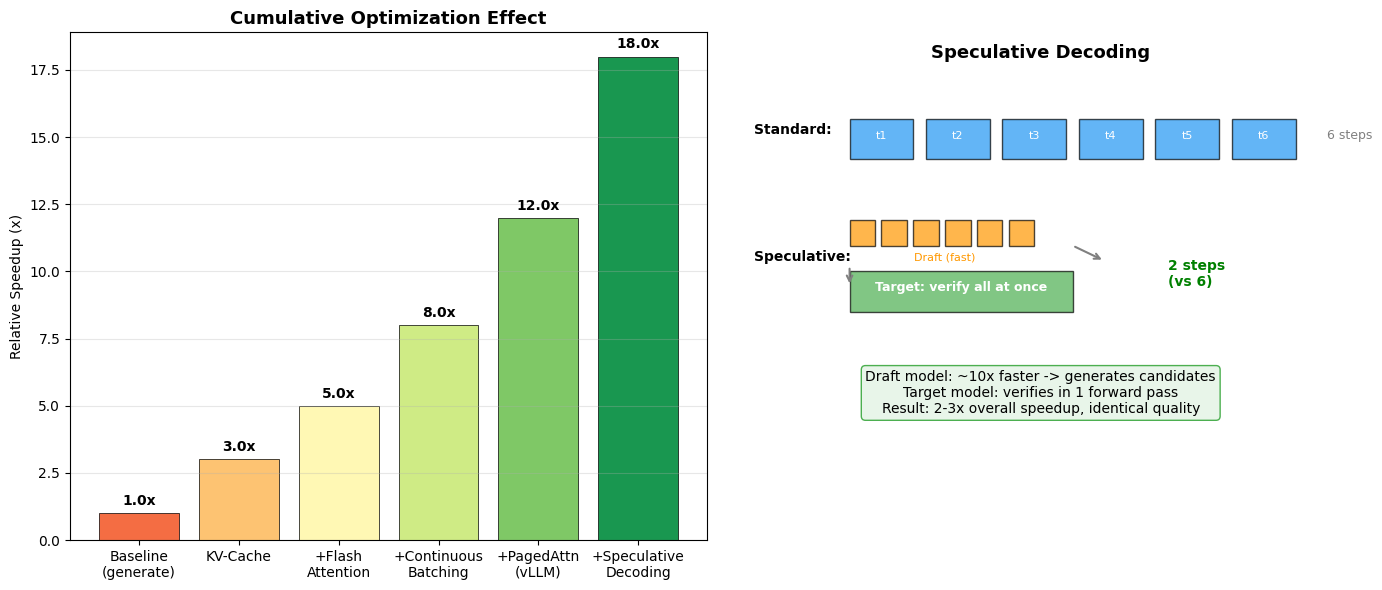

In [9]:
# 최적화 기법별 효과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Speed improvement by technique
techniques = ['Baseline\n(generate)', 'KV-Cache', '+Flash\nAttention', '+Continuous\nBatching', '+PagedAttn\n(vLLM)', '+Speculative\nDecoding']
speedup = [1.0, 3.0, 5.0, 8.0, 12.0, 18.0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(techniques)))

bars = axes[0].bar(techniques, speedup, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Relative Speedup (x)')
axes[0].set_title('Cumulative Optimization Effect', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for bar, s in zip(bars, speedup):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{s}x', ha='center', fontsize=10, fontweight='bold')

# Panel 2: Speculative Decoding illustration
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'Speculative Decoding', ha='center', fontsize=13, fontweight='bold')

# Standard decoding
ax.text(0.5, 8.0, 'Standard:', fontsize=10, fontweight='bold')
for i in range(6):
    color = '#2196F3'
    ax.add_patch(plt.Rectangle((2 + i * 1.2, 7.5), 1.0, 0.8, 
                                facecolor=color, alpha=0.7, edgecolor='black'))
    ax.text(2.5 + i * 1.2, 7.9, f't{i+1}', ha='center', fontsize=8, color='white')
ax.text(9.5, 7.9, '6 steps', fontsize=9, color='gray')

# Speculative decoding
ax.text(0.5, 5.5, 'Speculative:', fontsize=10, fontweight='bold')

# Draft model (small, fast)
for i in range(6):
    ax.add_patch(plt.Rectangle((2 + i * 0.5, 5.8), 0.4, 0.5, 
                                facecolor='#FF9800', alpha=0.7, edgecolor='black'))
ax.text(2 + 3 * 0.5, 5.5, 'Draft (fast)', ha='center', fontsize=8, color='#FF9800')

# Target model (large, verify)
ax.add_patch(plt.Rectangle((2, 4.5), 3.5, 0.8, facecolor='#4CAF50', alpha=0.7, edgecolor='black'))
ax.text(3.75, 4.9, 'Target: verify all at once', ha='center', fontsize=9, color='white', fontweight='bold')

ax.annotate('', xy=(6, 5.5), xytext=(5.5, 5.8), arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.annotate('', xy=(2, 5.0), xytext=(2, 5.4), arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))

ax.text(7, 5.0, '2 steps\n(vs 6)', fontsize=10, color='green', fontweight='bold')

# Speedup note
ax.text(5, 2.5, 'Draft model: ~10x faster -> generates candidates\n'
                 'Target model: verifies in 1 forward pass\n'
                 'Result: 2-3x overall speedup, identical quality',
        ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='#E8F5E9', edgecolor='#4CAF50'))

plt.tight_layout()
plt.show()

In [10]:
# 성능 벤치마크 시뮬레이션
print("추론 성능 벤치마크 (시뮬레이션)")
print("=" * 70)
print(f"{'Method':<25} {'Tokens/s':>10} {'Latency(ms)':>12} {'Memory(GB)':>11} {'Concurrent':>10}")
print("-" * 70)

benchmarks = [
    ("HF generate() (FP16)", 42, 1200, 3.0, 1),
    ("HF generate() (INT4)", 58, 850, 0.9, 1),
    ("HF pipeline (batch=4)", 95, 680, 3.2, 4),
    ("vLLM (FP16)", 165, 320, 3.5, 32),
    ("vLLM (AWQ 4-bit)", 210, 240, 1.2, 64),
    ("vLLM + Flash Attn", 230, 220, 1.0, 64),
]

for name, tps, latency, mem, concurrent in benchmarks:
    print(f"{name:<25} {tps:>10} {latency:>12} {mem:>10.1f} {concurrent:>10}")

print("\n" + "=" * 70)
print("참고:")
print("  - 위 수치는 Qwen 1.5B, 256 tokens 생성 기준 시뮬레이션")
print("  - 실제 수치는 하드웨어, 모델, 입력 길이에 따라 달라짐")
print("  - vLLM의 진짜 장점은 동시 요청 처리 (Concurrent 열)")

추론 성능 벤치마크 (시뮬레이션)
Method                      Tokens/s  Latency(ms)  Memory(GB) Concurrent
----------------------------------------------------------------------
HF generate() (FP16)              42         1200        3.0          1
HF generate() (INT4)              58          850        0.9          1
HF pipeline (batch=4)             95          680        3.2          4
vLLM (FP16)                      165          320        3.5         32
vLLM (AWQ 4-bit)                 210          240        1.2         64
vLLM + Flash Attn                230          220        1.0         64

참고:
  - 위 수치는 Qwen 1.5B, 256 tokens 생성 기준 시뮬레이션
  - 실제 수치는 하드웨어, 모델, 입력 길이에 따라 달라짐
  - vLLM의 진짜 장점은 동시 요청 처리 (Concurrent 열)


---
## 7. 핵심 정리

### 이번 노트북에서 배운 것
1. **model.generate() 한계**: 동기, Static Batching, 메모리 단편화
2. **KV-Cache**: O(n^2) → O(n), 메모리-속도 tradeoff
3. **PagedAttention**: KV-Cache 단편화 해결, 메모리 활용률 +30-50%
4. **Continuous Batching**: GPU 쉬는 시간 제거, 처리량 +2-3x
5. **vLLM**: OpenAI-compatible API, 양자화 모델 지원
6. **FastAPI 서버**: 커스텀 로직 + vLLM (Windows는 HF fallback)
7. **Flash Attention**: SRAM 활용, 속도 2-4x
8. **Speculative Decoding**: Draft + Target, 속도 2-3x, 품질 동일

### 플랫폼별 가이드
| 플랫폼 | 추천 방식 |
|--------|--------|
| Linux 서버 | vLLM (AWQ) + FastAPI |
| Windows (WSL2) | vLLM in WSL2 |
| Windows (native) | HF pipeline + FastAPI |
| 로컬 (모든 OS) | Ollama (Phase 8-3) |

> **핵심 원칙**: 추론 최적화의 본질은 '모델을 빠르게 하는 것'이 아니라 'GPU의 빈 시간을 없애는 것'이다.

In [11]:
# Phase 8-2 체크포인트
checkpoint = {
    "phase": "8-2",
    "title": "추론 서버와 최적화",
    "completed": [
        "model.generate() 한계 이해",
        "KV-Cache 원리와 O(n^2)->O(n) 개선",
        "PagedAttention + Continuous Batching",
        "vLLM 서버 실행 + API 호출",
        "FastAPI + vLLM 커스텀 서버",
        "Windows HF pipeline fallback",
        "Flash Attention, Speculative Decoding 개념",
        "성능 벤치마크 비교",
    ],
    "next": "Phase 8-3: 배포 옵션과 프로덕션",
}

print("Phase 8-2 체크포인트")
print("=" * 50)
for item in checkpoint["completed"]:
    print(f"  [v] {item}")
print(f"\n다음: {checkpoint['next']}")

Phase 8-2 체크포인트
  [v] model.generate() 한계 이해
  [v] KV-Cache 원리와 O(n^2)->O(n) 개선
  [v] PagedAttention + Continuous Batching
  [v] vLLM 서버 실행 + API 호출
  [v] FastAPI + vLLM 커스텀 서버
  [v] Windows HF pipeline fallback
  [v] Flash Attention, Speculative Decoding 개념
  [v] 성능 벤치마크 비교

다음: Phase 8-3: 배포 옵션과 프로덕션
